Testing with vertical drop example from P387 of Brody et al.

$$
v' = -kC_d v^2-g
$$

Looking for hitting the ground (-30 m) at $v=21.006$m/s after $1.6199$s.

Through testing it is found that the first term on the right is missing a $\sin\theta$ term, where $\theta$ is $\frac{3\pi}{2}$, negating the term.

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt

# constants, all with respect to kilogram, meter, and seconds when applicable
# for testing all from P387 vertical drop test
c_d = 0.5
rho = 1.21
r = 0.0325
m = 0.057
k = rho*math.pi*r**2/(2*m)
g = 9.8

# initial conditions, set for each shot, also change vectorfield and timepoints below accordingly
v0 = -15 # m/s

In [2]:
from scipy.integrate import odeint # scipy-cookbook.readthedocs.io/items/CoupledSpringMassSystem.html

In [3]:
def testing_equation(w, t, p):
    v, a = w
    k, c_d, g = p
    f = [k*c_d*v**2-g, 0]
    #f = [-k*c_d*v**2-g, 0] # !!! Key change here - drag should be acting counter to gravity
    return f

In [4]:
# Set-up from the cookbook example
# ODE solver parameters
# adjust stoptime and numpoints for each shot
abserr = 1.0e-8
relerr = 1.0e-6
stoptime = 2
numpoints = 500
# Create the time samples for the output of the ODE solver
t = [stoptime * float(i) / (numpoints - 1) for i in range(numpoints)]
# Pack up the parameters and initial conditions:
p = [k, c_d, g]
w0 = [v0, 1]
vectorfield = testing_equation

In [5]:
# Call the ODE solver.
wsol = odeint(vectorfield, w0, t, args=(p,), atol=abserr, rtol=relerr)

#### land_x - cutoff at 30 m

In [6]:
unit_t = stoptime/(numpoints-1)
x = [0]*(numpoints+1)
for i in range(numpoints):
    x[i+1] = x[i] + unit_t*wsol[i,0]
land_x = np.argmax(np.array(x) <= -30)

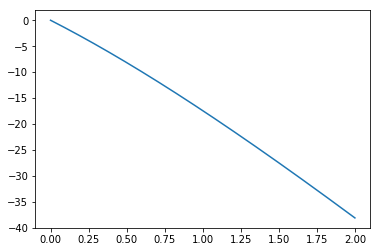

In [7]:
plt.plot(t,x[:numpoints])

In [8]:
x[land_x]

-30.05779116099612

In [9]:
wsol[land_x,:] # speed should be around -21m

array([-21.0127923,   1.       ])

In [10]:
t[land_x] # time should be around 1.62s

1.623246492985972

#### land_t - cutoff at t = 1.6199 s

In [11]:
land_t = np.argmax(np.array(t) >= 1.6199)
t[land_t]

1.623246492985972

In [12]:
wsol[land_t,0] # speed should be around -21m/s

-21.01279230197949

#### land_v - cutoff at 21.006 m/s

In [13]:
land_v = np.argmax(np.array(wsol[:,0]) <= -21.006)

In [14]:
t[land_v] # should be around 1.62s

1.623246492985972